# Round 3: Energy Comparison (Linux vs Unikernel)

Using the non-failed datasets from `round3/` to compare package energy (pkg_joules) per run.

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn theme
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

## 2. Load Round 3 CSVs (non-failed)

In [3]:
# Paths
linux_path = 'round3/bubblesort-beeps-linux-asis.csv'
unikernel_path = 'round3/bubblesort-beeps-unikernel-asis.csv'  # exclude the failed one

# Load
linux_r3 = pd.read_csv(linux_path)
unikernel_r3 = pd.read_csv(unikernel_path)

# Add run number
linux_r3['run'] = range(1, len(linux_r3) + 1)
unikernel_r3['run'] = range(1, len(unikernel_r3) + 1)

# Quick preview
print('Linux round3 shape:', linux_r3.shape)
print('Unikernel round3 shape:', unikernel_r3.shape)
linux_r3.head()

Linux round3 shape: (50, 11)
Unikernel round3 shape: (50, 11)


,benchmark,cpu_cycles,cycles_start,cycles_end,pkg_joules,pkg_mJ,dram_joules,dram_mJ,total_joules,total_mJ,run
0,bubblesort,59748151104,2301893543014,2361641694118,330.532318,330532.318,NaN,NaN,330.532318,330532.318,1
1,bubblesort,59734793818,2361641833025,2421376626843,331.824860,331824.860,NaN,NaN,331.824860,331824.860,2
2,bubblesort,59734604949,2421376715778,2481111320727,332.826614,332826.614,NaN,NaN,332.826614,332826.614,3
3,bubblesort,59732897474,2481111407491,2540844304965,333.893860,333893.860,NaN,NaN,333.893860,333893.860,4
4,bubblesort,59734621856,2540844392358,2600579014214,334.026703,334026.703,NaN,NaN,334.026703,334026.703,5


## Round 3 energy (non-failing)

We plot pkg_joules for Linux vs Unikernel using a per-run line plot and an overall distribution boxplot.

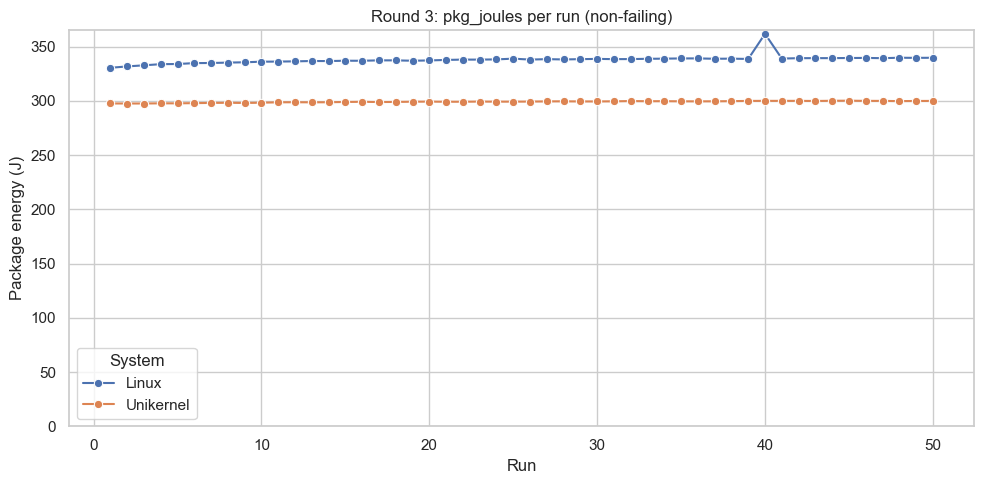

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Prepare combined dataframe from existing round 3 dataframes
linux_df = linux_r3.copy().reset_index(drop=True)
unikernel_df = unikernel_r3.copy().reset_index(drop=True)

linux_df['run'] = np.arange(1, len(linux_df) + 1)
unikernel_df['run'] = np.arange(1, len(unikernel_df) + 1)

linux_df['system'] = 'Linux'
unikernel_df['system'] = 'Unikernel'

combined = pd.concat([
    linux_df[['run', 'system', 'pkg_joules']],
    unikernel_df[['run', 'system', 'pkg_joules']]
], ignore_index=True)

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=combined, x='run', y='pkg_joules', hue='system', marker='o')
ax.set_title('Round 3: pkg_joules per run (non-failing)')
ax.set_xlabel('Run')
ax.set_ylabel('Package energy (J)')
ax.set_ylim(0, None)
ax.legend(title='System')
plt.tight_layout()
plt.show()

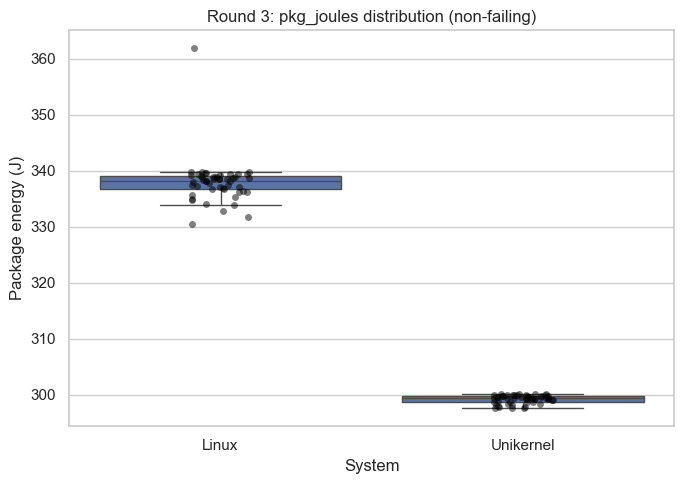

           count        mean       std         min         max
system                                                        
Linux       50.0  338.000180  4.050959  330.532318  361.876434
Unikernel   50.0  299.224534  0.767653  297.608062  300.214096


In [5]:
# Boxplot of pkg_joules by system with strip overlay and basic stats
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=combined, x='system', y='pkg_joules', showfliers=False)
sns.stripplot(data=combined, x='system', y='pkg_joules', color='black', alpha=0.5, jitter=0.1)
ax.set_title('Round 3: pkg_joules distribution (non-failing)')
ax.set_xlabel('System')
ax.set_ylabel('Package energy (J)')
# ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

# Summary stats
summary = combined.groupby('system')['pkg_joules'].describe()[['count','mean','std','min','max']]
print(summary)

## CDF of pkg_joules (Round 3)

Empirical CDF for Linux vs Unikernel using pkg_joules.

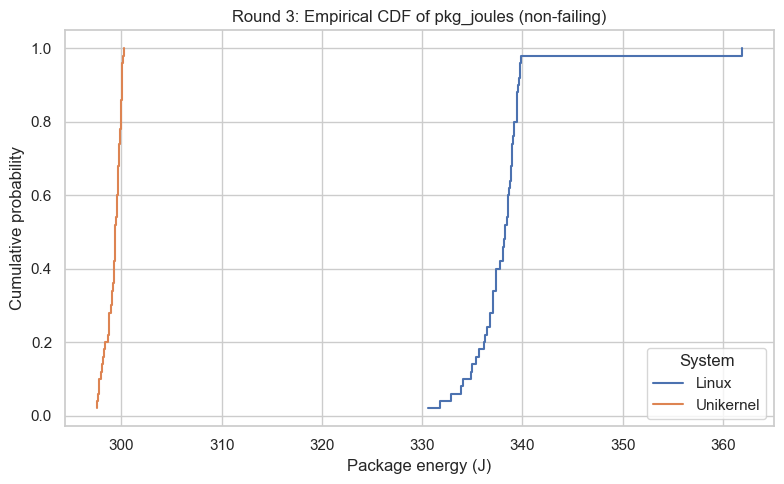

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for system, df in combined.groupby('system'):
    x = np.sort(df['pkg_joules'].values)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=system)

plt.title('Round 3: Empirical CDF of pkg_joules (non-failing)')
plt.xlabel('Package energy (J)')
plt.ylabel('Cumulative probability')
plt.legend(title='System')
plt.tight_layout()
plt.show()

## Boxplot (non-zero baseline)

Same boxplot without forcing y-axis to start at zero, to better resolve small differences.

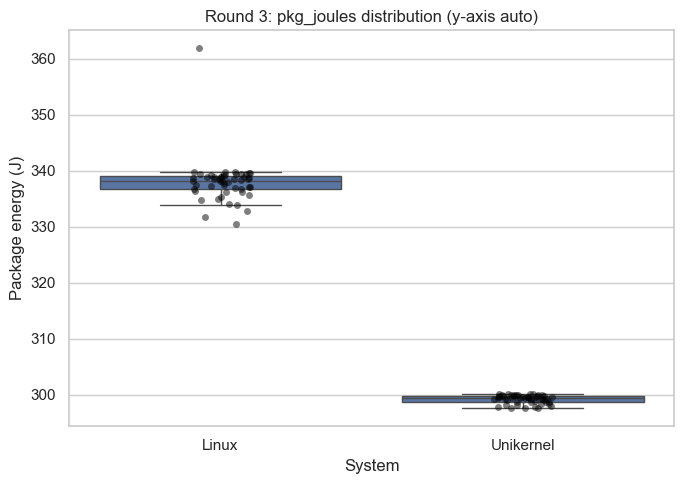

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=combined, x='system', y='pkg_joules', showfliers=False)
sns.stripplot(data=combined, x='system', y='pkg_joules', color='black', alpha=0.5, jitter=0.1)
ax.set_title('Round 3: pkg_joules distribution (y-axis auto)')
ax.set_xlabel('System')
ax.set_ylabel('Package energy (J)')
# Note: no ax.set_ylim(0, None) here on purpose
plt.tight_layout()
plt.show()

## Runtime comparison (cpu_cycles)

We compare cpu_cycles per run as a proxy for runtime (cycles are hardware counter values).

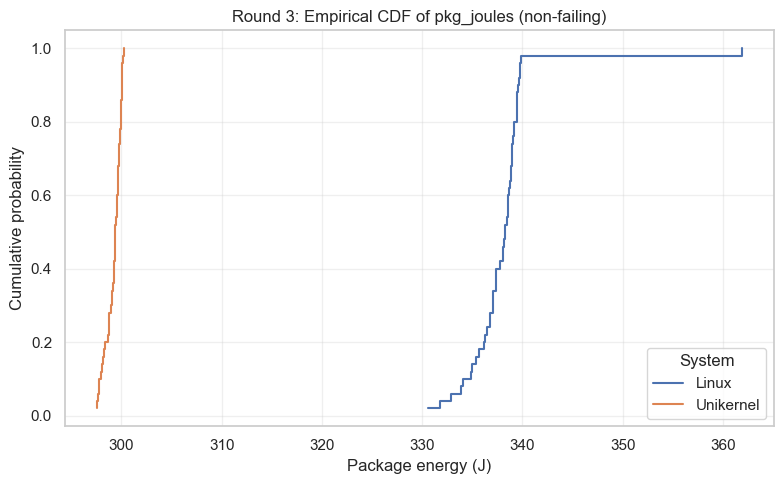

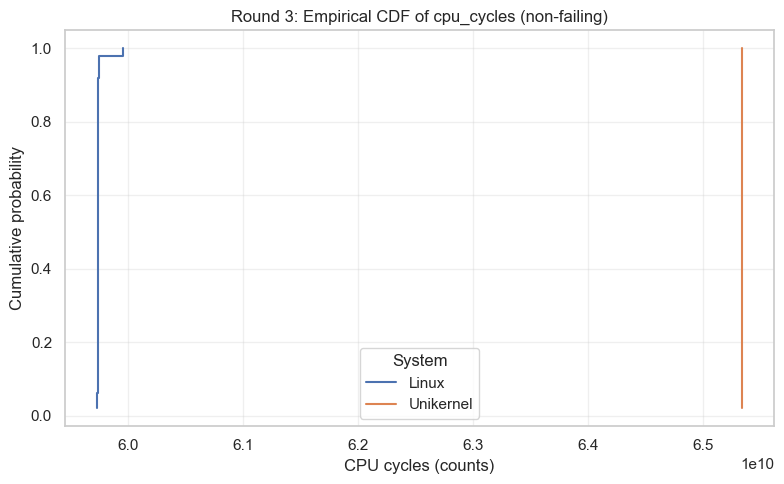

In [8]:
# Build cycles-combined dataframe
linux_cycles = linux_r3[['run','cpu_cycles']].copy()
linux_cycles['system'] = 'Linux'
unikernel_cycles = unikernel_r3[['run','cpu_cycles']].copy()
unikernel_cycles['system'] = 'Unikernel'
cycles_combined = pd.concat([linux_cycles, unikernel_cycles], ignore_index=True)

# ECDF for pkg_joules (energy)
plt.figure(figsize=(8,5))
for system, df in combined.groupby('system'):
    x = np.sort(df['pkg_joules'].values)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=system)
plt.title('Round 3: Empirical CDF of pkg_joules (non-failing)')
plt.xlabel('Package energy (J)')
plt.ylabel('Cumulative probability')
plt.legend(title='System')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ECDF for cpu_cycles (running times)
plt.figure(figsize=(8,5))
for system, df in cycles_combined.groupby('system'):
    x = np.sort(df['cpu_cycles'].values)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=system)
plt.title('Round 3: Empirical CDF of cpu_cycles (non-failing)')
plt.xlabel('CPU cycles (counts)')
plt.ylabel('Cumulative probability')
plt.legend(title='System')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()